## Regularization - Weights & Biases decay
The goal of this notebook is to test the effect of regularization, in terms of weight and bias decay, on the performance of the SGD optimizer on a linear regression problem.
We will use a synthetic dataset generated from a known linear signal `f(x) = SLOPE*x + INTERCEPT`, with independent Gaussian noise added at a fixed level to produce several noisy realizations of the same underlying relationship.

# Training: decay in isolation

This experiment comprises three different scenarios:
In every scenario the signal used to generate the dataset is the same, and the noise level is fixed.
The only changes are the `x` points.

1. No weight decay
   - 1 dimension, several trials on different noise realizations of the same underlying signal with same noise level

2. Weight decay:
   - 1 dimension, several trials on different noise realizations of the same underlying signal with same noise level
   - 1 dimension for the decay coefficients, with increasing decay coefficients

3. Weight decay + Bias decay:
   - 1 dimension, several trials on different noise realizations of the same underlying signal with same noise level
   - 1 dimension for the decay coefficients, with increasing decay coefficients

# 1. No weight decay

In this scenario we train the model without any weight decay, on several
independent noisy realizations of the same signal drawn at a fixed noise
level, and evaluate its performance on the test set. We use a learning rate
scheduler and the SGD optimizer.
We also plot the training and validation loss curves to visualize the performance of the model.

In [66]:
"""Common hyper parameters across scenarios"""
SEED = 888
INTERCEPT = 25
BATCH_SIZE = 16
SAMPLE_SIZE = 100
EPOCHS = 25
N_TRIALS = 4
EVAL_STEP = 10
NOISE = 100
IN_FEATURE, OUT_FEATURE = 1, 1
SPLIT_RATIO = 0.9
MAX_LR, MIN_LR = 1e-2, 1e-4

In [67]:
"""Training over N_TRIALS independent noisy realizations of the same signal f(x), at the same fixed NOISE level, one trainer fitting each, to observe how weights and biases vary with a high variance dataset."""

from core.training.trainer import Trainer
from examples.linear_regression.helpers.dataset import generate_regression_repeats, preprocess_dataloader, split_dataset
from examples.linear_regression.helpers.train import create_trainer, fit_model



_, _, repeats, coef = generate_regression_repeats(N_TRIALS, SAMPLE_SIZE, IN_FEATURE, OUT_FEATURE, NOISE, INTERCEPT, SEED)
SLOPE = float(coef.item())
tr, te = split_dataset(repeats, split_ratio=SPLIT_RATIO, axis=1)

fitted_trainers:list[Trainer] = []

for sample_tr, sample_te in zip(tr, te):
    loader_tr, loader_te = preprocess_dataloader(sample_tr, sample_te, BATCH_SIZE, OUT_FEATURE)
    trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS)
    fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)
    fitted_trainers.append(trainer)


## 1.1 No weight decay: Loss history

The loss histories are plotted for each trial on the same graph, with train and evaluation loss shown in separate plots.

The dashed lines represent the optimal loss values for the training and evaluation sets, respectively.

The optimal loss value is computed as `OLS`.

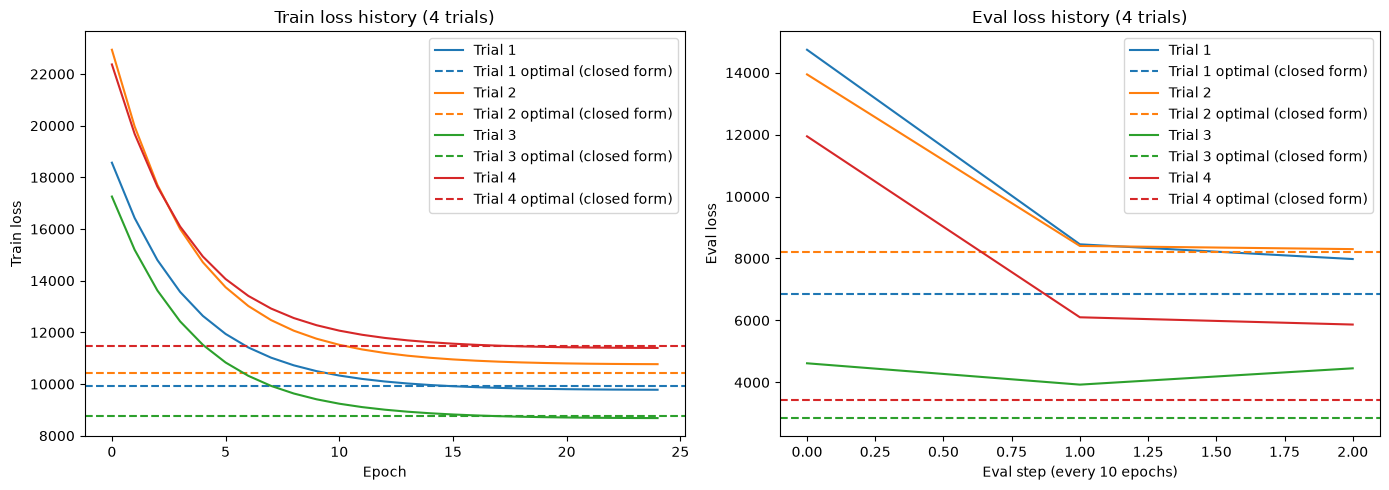

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from core.functions import mse
from examples.linear_regression.helpers.train import get_models_params


def param_magnitude(p: np.ndarray) -> float:
    """L2 norm of a weight/bias array, collapsing it to a single scalar for plotting."""
    return float(np.linalg.norm(p))

def closed_form_fit(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """OLS closed-form solution (W, b) minimizing mse(X @ W + b, y) on the given sample."""
    A = np.hstack([X, np.ones((X.shape[0], 1))])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coef[:-1], coef[-1]


params_history = get_models_params([trainer.model for trainer in fitted_trainers])
weights_history = np.array([param_magnitude(p[0]) for p in params_history])
bias_history = np.array([param_magnitude(p[1]) for p in params_history])

fig, (ax_train, ax_eval) = plt.subplots(1, 2, figsize=(14, 5))

for i, trainer in enumerate(fitted_trainers):
    line, = ax_train.plot(trainer.train_loss, label=f"Trial {i+1}")

    X_tr_i, y_tr_i = tr[i][:, :IN_FEATURE], tr[i][:, IN_FEATURE:]
    W_star, b_star = closed_form_fit(X_tr_i, y_tr_i)
    closed_form_loss_tr = mse(X_tr_i @ W_star + b_star, y_tr_i)
    ax_train.axhline(closed_form_loss_tr, color=line.get_color(), linestyle="dashed", label=f"Trial {i+1} optimal (closed form)")
ax_train.set_xlabel("Epoch")
ax_train.set_ylabel("Train loss")
ax_train.set_title(f"Train loss history ({N_TRIALS} trials)")
ax_train.legend()

for i, trainer in enumerate(fitted_trainers):
    line, = ax_eval.plot(trainer.eval_loss, label=f"Trial {i+1}")

    X_te_i, y_te_i = te[i][:, :IN_FEATURE], te[i][:, IN_FEATURE:]
    W_star, b_star = closed_form_fit(X_te_i, y_te_i)
    closed_form_loss_te = mse(X_te_i @ W_star + b_star, y_te_i)
    ax_eval.axhline(closed_form_loss_te, color=line.get_color(), linestyle="dashed", label=f"Trial {i+1} optimal (closed form)")
ax_eval.set_xlabel(f"Eval step (every {EVAL_STEP} epochs)")
ax_eval.set_ylabel("Eval loss")
ax_eval.set_title(f"Eval loss history ({N_TRIALS} trials)")
ax_eval.legend()

fig.tight_layout()
plt.show()


## 1.2 Loss history interpretation

As you can see, the eval losses, don't decreas as well as the train losses, and this is because high variance in targets, produce bad generalization, and the model is not able to learn the underlying signal, but only the noise.

## 1.3  Weights and Biases interpretation

The goal of the charts below is to show how in an high variance dataset, the learned weights and biases are spread across trials.


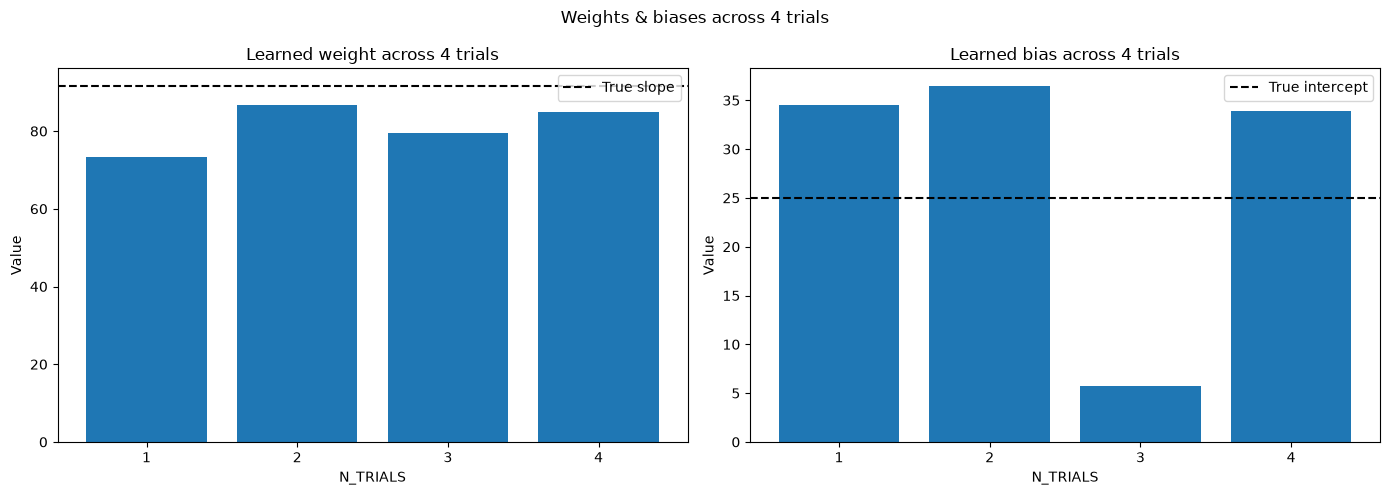

In [69]:

trials = np.arange(1, N_TRIALS + 1)

fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(14, 5))

ax_w.bar(trials, weights_history)
ax_w.axhline(SLOPE, color="black", linestyle="dashed", label="True slope")
ax_w.set_xticks(trials)
ax_w.set_xlabel("N_TRIALS")
ax_w.set_ylabel("Value")
ax_w.set_title(f"Learned weight across {N_TRIALS} trials")
ax_w.legend()

ax_b.bar(trials, bias_history)
ax_b.axhline(INTERCEPT, color="black", linestyle="dashed", label="True intercept")
ax_b.set_xticks(trials)
ax_b.set_xlabel("N_TRIALS")
ax_b.set_ylabel("Value")
ax_b.set_title(f"Learned bias across {N_TRIALS} trials")
ax_b.legend()

fig.suptitle(f"Weights & biases across {N_TRIALS} trials")
fig.tight_layout()
plt.show()

# 2. Weight decay

In this scenario, we train over several `N_TRIALS`, indipendent noisy realization of the same underling signal, with increasing weight decay coefficient.


The goal is to show, how weight decay reduce the variance of the learned weights and biases, and how it affects the loss history.

In [70]:
import numpy as np
from core.training.trainer import Trainer
from examples.linear_regression.helpers.train import create_trainer, fit_model


DECAY_UPTO = 4
DECAY_DISTANCE = 0.2
TOTAL_DECAY_TERMS = int(DECAY_UPTO/DECAY_DISTANCE)

decay_coefs = np.linspace(0, DECAY_UPTO, TOTAL_DECAY_TERMS)
_, _, repeats, _ = generate_regression_repeats(N_TRIALS, SAMPLE_SIZE, IN_FEATURE, OUT_FEATURE, NOISE, INTERCEPT, SEED)
tr, te = split_dataset(repeats, split_ratio=SPLIT_RATIO, axis=1)

all_trainers:list[Trainer] = []
for sample_tr, sample_te in zip(tr, te):   
    loader_tr, loader_te = preprocess_dataloader(sample_tr, sample_te, BATCH_SIZE, OUT_FEATURE)
    
    trainers:list[Trainer] = []
    for decay in decay_coefs:
        trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS, decay)
        trainers.append(trainer)
        fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)
    all_trainers.append(trainers)

## 2.2 Weights and Biases spread across decay coefficients

The goal of the chart below is to show how increasing the weight decay coefficient reduces the spread of the learned weights and biases across the `N_TRIALS` trials.

The weights are shrinked towards zero, this is the weights decay effect.

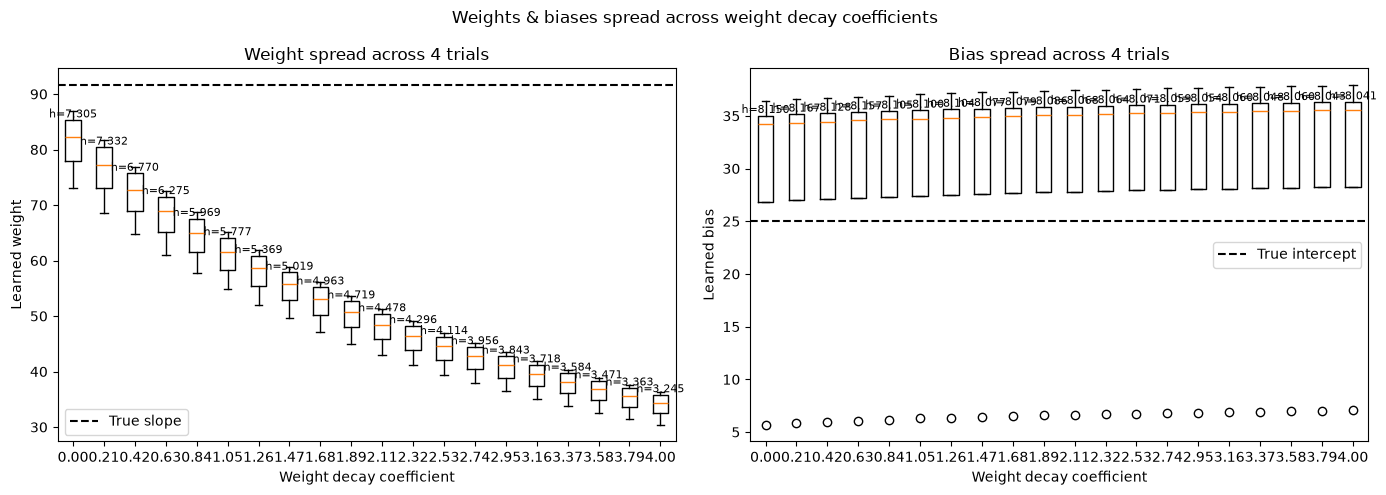

In [71]:
from examples.linear_regression.helpers.train import get_models_params

weights_by_decay = []
bias_by_decay = []

for j in range(len(decay_coefs)):
    models = [all_trainers[i][j].model for i in range(N_TRIALS)]
    params = get_models_params(models)
    weights_by_decay.append(np.array([param_magnitude(p) for p in params[:, 0]]))
    bias_by_decay.append(np.array([param_magnitude(p) for p in params[:, 1]]))

decay_labels = [f"{decay:.2f}" for decay in decay_coefs]

def annotate_box_heights(ax, bp):
    """Label each box with its height (Q3 - Q1), so spreads can be compared at a glance."""
    for box in bp["boxes"]:
        x_data, y_data = box.get_xdata(), box.get_ydata()
        y_top, y_bottom = y_data.max(), y_data.min()
        ax.text((x_data.min() + x_data.max()) / 2, y_top, f"h={y_top - y_bottom:.3f}",
                ha="center", va="bottom", fontsize=8)

fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(14, 5))

bp_w = ax_w.boxplot(weights_by_decay, tick_labels=decay_labels)
annotate_box_heights(ax_w, bp_w)
ax_w.axhline(SLOPE, color="black", linestyle="dashed", label="True slope")
ax_w.set_xlabel("Weight decay coefficient")
ax_w.set_ylabel("Learned weight")
ax_w.set_title(f"Weight spread across {N_TRIALS} trials")
ax_w.legend()

bp_b = ax_b.boxplot(bias_by_decay, tick_labels=decay_labels)
annotate_box_heights(ax_b, bp_b)
ax_b.axhline(INTERCEPT, color="black", linestyle="dashed", label="True intercept")
ax_b.set_xlabel("Weight decay coefficient")
ax_b.set_ylabel("Learned bias")
ax_b.set_title(f"Bias spread across {N_TRIALS} trials")
ax_b.legend()

fig.suptitle("Weights & biases spread across weight decay coefficients")
fig.tight_layout()
plt.show()

## 2.3 Decay rate validation curve

The graph below shows the mean test loss across the `N_TRIALS` trials, for each decay coefficient.

The red marker is the argmin point, the sweet spot for the best decay coefficient — it is the one that produces the lowest mean test loss across trials.

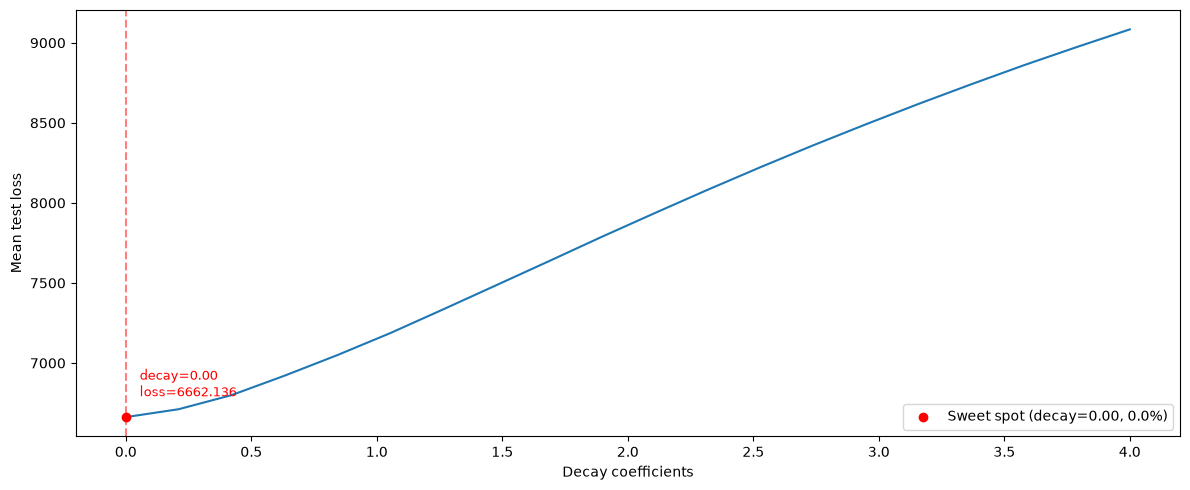

In [72]:
import matplotlib.pyplot as plt

test_mse_decay = []
for j in range(len(decay_coefs)):
    losses = [all_trainers[i][j].eval_loss[-1] for i in range(N_TRIALS)]
    test_mse_decay.append(np.mean(losses))

best_idx = int(np.argmin(test_mse_decay))
best_decay, best_loss = decay_coefs[best_idx], test_mse_decay[best_idx]

no_decay_loss = test_mse_decay[0]
improvement_pct = (no_decay_loss - best_loss) / no_decay_loss * 100

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(decay_coefs, test_mse_decay)
ax.scatter([best_decay], [best_loss], color="red", zorder=5, label=f"Sweet spot (decay={best_decay:.2f}, {improvement_pct:.1f}%)")
ax.axvline(best_decay, color="red", linestyle="dashed", alpha=0.5)
ax.annotate(f"decay={best_decay:.2f}\nloss={best_loss:.3f}",
            xy=(best_decay, best_loss), xytext=(10, 15), textcoords="offset points",
            fontsize=9, color="red")
ax.set_ylabel("Mean test loss")
ax.set_xlabel(f"Decay coefficients")
ax.legend()

fig.tight_layout()
plt.show()